In [ ]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics
import yfinance as yf

from prophet  import Prophet
from openpyxl import load_workbook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, accuracy_score, silhouette_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier


# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

## * Prophet 라이브러리를 사용하여 100일 후 주가 예측하기

#### 1. 데이터 수집

In [5]:
# 구글 주가 데이터 파일 읽어오기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

stock = pd.read_csv('../../data/GOOG.csv', header=0)
stock.head()

,Date,GOOG
0,2020-01-02,67.859535
1,2020-01-03,67.526527
2,2020-01-06,69.191559
3,2020-01-07,69.148376
4,2020-01-08,69.693298


#### 2. 데이터 준비

In [7]:
## Prophet 모델의 입력 조건에 따라 열이름 변경
stock.columns = ['ds', 'y']
stock.head()

,ds,y
0,2020-01-02,67.859535
1,2020-01-03,67.526527
2,2020-01-06,69.191559
3,2020-01-07,69.148376
4,2020-01-08,69.693298


In [8]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ds      1529 non-null   object 
 1   y       1529 non-null   float64
dtypes: float64(1), object(1)
memory usage: 24.0+ KB


In [ ]:
## Prophet 모델의 입력 조건에 따라 데이터 타입 변경
# ds 열을 datetime 형식으로 변환
stock['ds'] = pd.to_datetime(stock['ds'])
stock.info()

# stock['ds'] = stock['ds'].astype('datetime64')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      1529 non-null   datetime64[ns]
 1   y       1529 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 24.0 KB


#### 3. 모델구축

In [10]:
from prophet  import Prophet

##### 1) Prophet 모델 생성

In [ ]:
# Prophet 모델 객체 생성
pp_stock = Prophet()     # 기본적으로 80% 신뢰구간

# pp_stock = Prophet(interval_width=0.95)   # 95% 신뢰구간

##### 2) Prophet 모델 학습

In [12]:
pp_stock.fit(stock)

20:27:57 - cmdstanpy - INFO - Chain [1] start processing
20:27:58 - cmdstanpy - INFO - Chain [1] done processing


##### 3) 100일 후의 값 예측하기

In [13]:
future_ds = pp_stock.make_future_dataframe(periods=100) # 지정된 기간(100)만큼 미래 날짜 설정
future_ds.tail()

,ds
1624,2026-05-09
1625,2026-05-10
1626,2026-05-11
1627,2026-05-12
1628,2026-05-13


In [14]:
future_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1629 entries, 0 to 1628
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      1629 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 12.9 KB


In [15]:
# 미래 날짜(ds)에 대한 예측값(y) 생성
future_y = pp_stock.predict(future_ds)

future_y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1629 entries, 0 to 1628
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ds                          1629 non-null   datetime64[ns]
 1   trend                       1629 non-null   float64       
 2   yhat_lower                  1629 non-null   float64       
 3   yhat_upper                  1629 non-null   float64       
 4   trend_lower                 1629 non-null   float64       
 5   trend_upper                 1629 non-null   float64       
 6   additive_terms              1629 non-null   float64       
 7   additive_terms_lower        1629 non-null   float64       
 8   additive_terms_upper        1629 non-null   float64       
 9   weekly                      1629 non-null   float64       
 10  weekly_lower                1629 non-null   float64       
 11  weekly_upper                1629 non-null   float64     

In [16]:
future_y[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1624,2026-05-09,306.198994,287.038285,326.516852
1625,2026-05-10,306.640007,287.714101,326.124777
1626,2026-05-11,306.796340,288.035085,325.247926
1627,2026-05-12,306.949355,289.102321,325.856381
1628,2026-05-13,307.461205,289.630453,327.311832


#### 4. 시각화

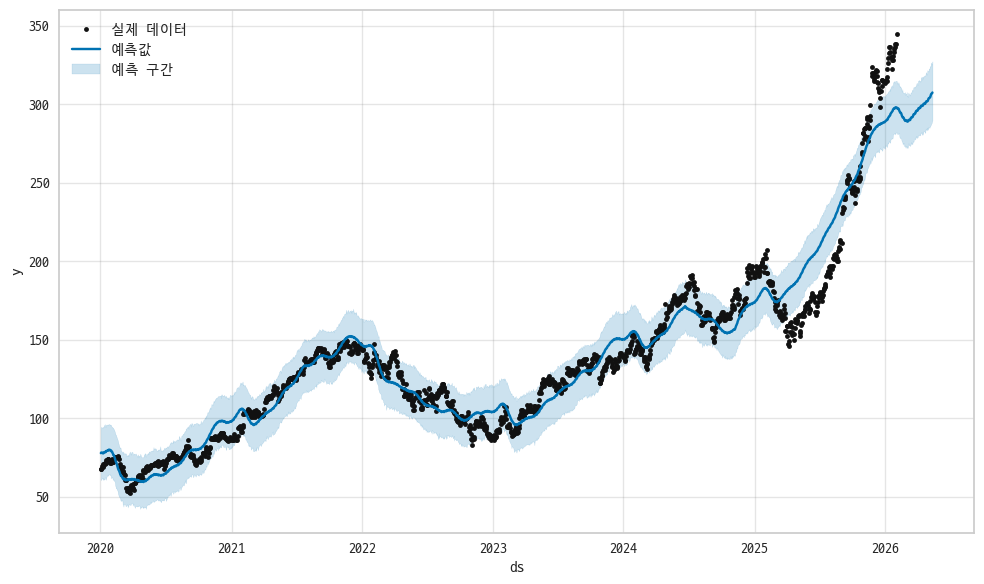

In [17]:
fig_trend = pp_stock.plot(future_y)

plt.legend(['실제 데이터', '예측값', '예측 구간'])
plt.show()

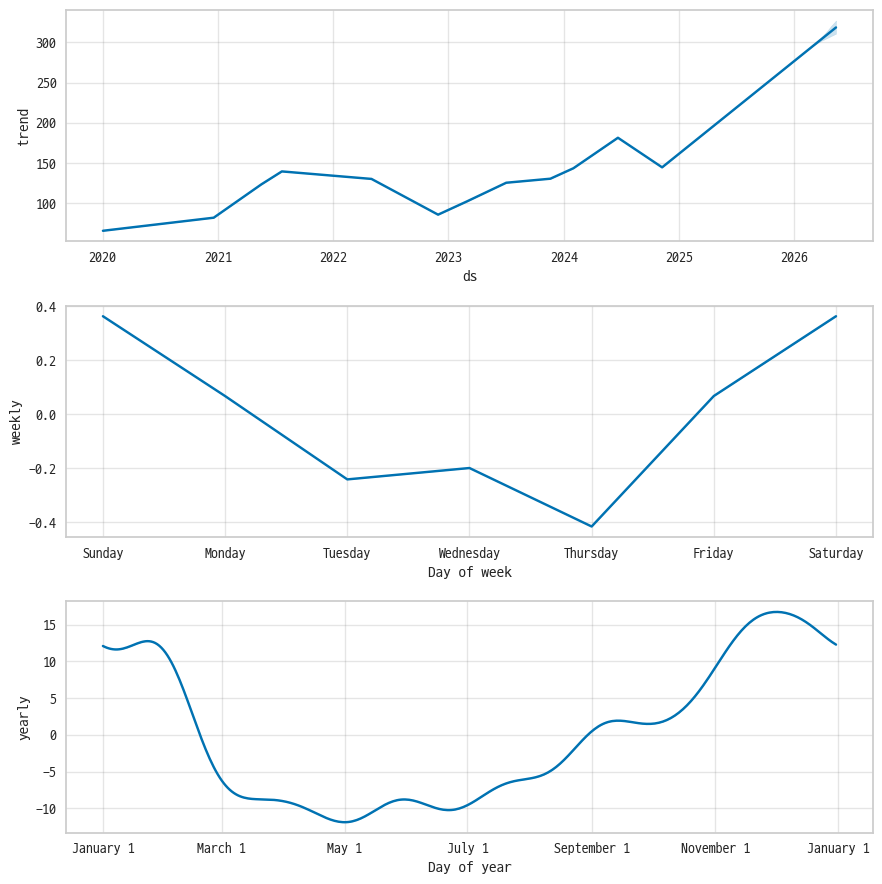

In [18]:
fig_components = pp_stock.plot_components(future_y)

# Trend (트렌드): 시계열 데이터에서 시간에 따른 주요 흐름
# Weekly Seasonality (주간 계절성): 주 단위의 패턴을 시각화
# Yearly Seasonality (연간 계절성): 연 단위의 패턴을 시각화

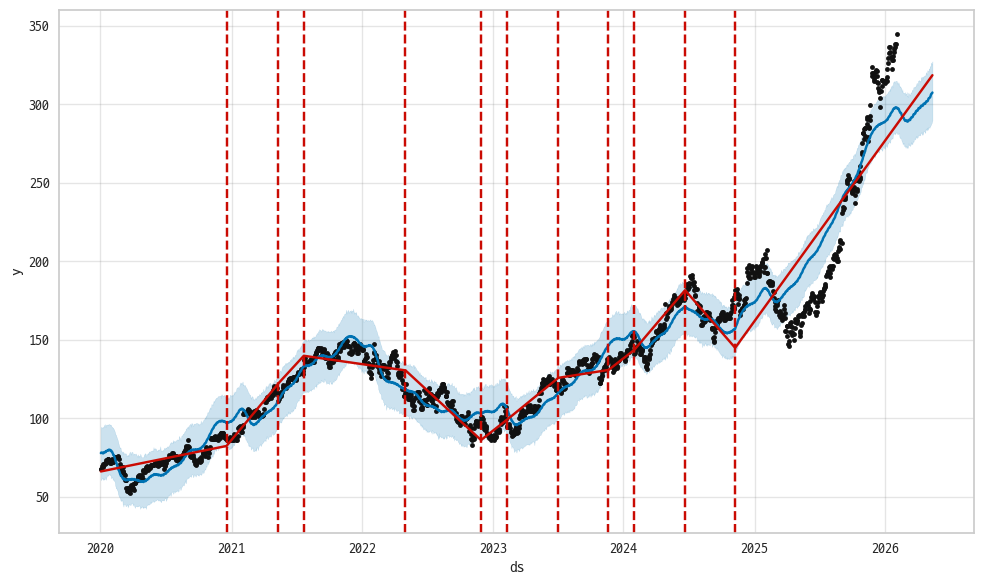

In [19]:
## 변화 시점 시각화
from prophet.plot import add_changepoints_to_plot

fig_trend = pp_stock.plot(future_y)  # 예측 결과를 시각화
fig_trend_changepoints = add_changepoints_to_plot(fig_trend.gca(), pp_stock, future_y)  # 변화점을 추가

In [20]:
### Prophet 대화형 그래프

from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(pp_stock, future_y)